In [1]:

import pandas as pd
import matplotlib.pyplot as plt
import json
from pathlib import Path

df = pd.read_csv("../data/raw/churn_data.csv")

Path("../reports/figures").mkdir(parents=True, exist_ok=True)

In [2]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   tenure_months     5000 non-null   int64  
 1   monthly_charges   5000 non-null   float64
 2   contract_type     5000 non-null   object 
 3   internet_service  5000 non-null   object 
 4   payment_method    5000 non-null   object 
 5   churn             5000 non-null   int64  
dtypes: float64(1), int64(2), object(3)
memory usage: 234.5+ KB


,tenure_months,monthly_charges,churn
count,5000.000000,5000.000000,5000.000000
mean,35.907400,70.953105,0.223400
std,20.551255,28.692167,0.416566
min,1.000000,20.000000,0.000000
25%,18.000000,50.103470,0.000000
50%,36.000000,69.937470,0.000000
75%,54.000000,90.606659,0.000000
max,71.000000,150.000000,1.000000


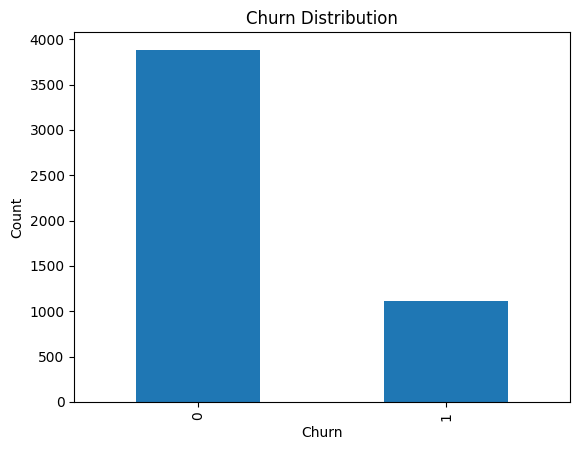

In [3]:
# churn distribution
df["churn"].value_counts().plot(kind="bar")
plt.title("Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Count")

plt.savefig("../reports/figures/churn_distribution.png", dpi=150)
plt.show()

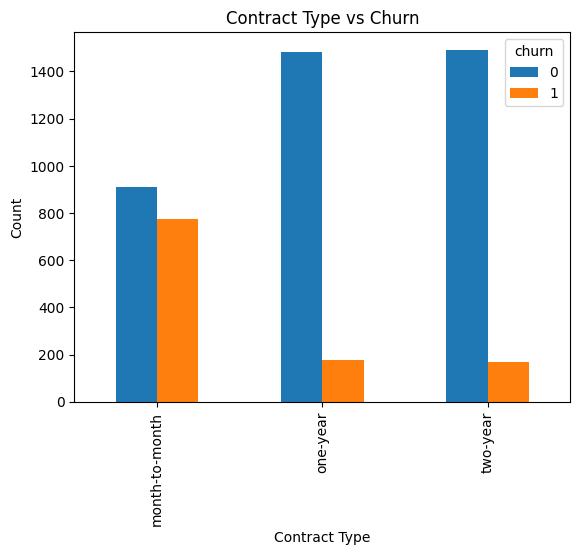

In [4]:
# contract vs churn
pd.crosstab(df["contract_type"], df["churn"]).plot(kind="bar")

plt.title("Contract Type vs Churn")
plt.xlabel("Contract Type")
plt.ylabel("Count")

plt.savefig("../reports/figures/contract_vs_churn.png", dpi=150)
plt.show()

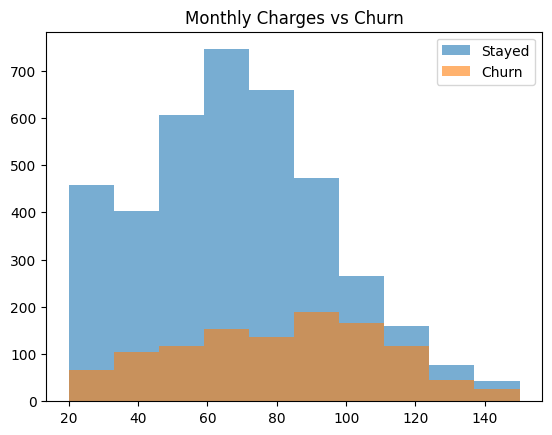

In [5]:
# charges vs churn
plt.hist(df[df["churn"]==0]["monthly_charges"], alpha=0.6, label="Stayed")
plt.hist(df[df["churn"]==1]["monthly_charges"], alpha=0.6, label="Churn")

plt.legend()
plt.title("Monthly Charges vs Churn")

plt.savefig("../reports/figures/charges_vs_churn.png", dpi=150)
plt.show()


In [6]:
summary = {
    "rows": len(df),
    "churn_rate": float(df["churn"].mean()),
    "avg_tenure": float(df["tenure_months"].mean()),
    "avg_charges": float(df["monthly_charges"].mean())
}

with open("../reports/eda_summary.json", "w") as f:
    json.dump(summary, f, indent=2)